# Email Spam Classifier

### A Machine Learning Mini Project

**Name:** _(Your Name)_  
**Roll Number:** _(Your Roll Number)_  
**Course:** B.Tech, 2nd Year  
**Subject:** Machine Learning / Artificial Intelligence  

---

## 1. Objective

The goal of this project is to build a machine learning model that can automatically classify an email (or SMS) message as either **Spam** or **Ham (Not Spam)**.

We use the **Bag of Words** technique to convert text data into numerical form, and a **Multinomial Naive Bayes** classifier — a widely used algorithm for text classification tasks — to train the model.

## 2. Import Required Libraries

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import ipywidgets as widgets
from IPython.display import display, clear_output

## 3. Load the Dataset

The dataset (`spam_dataset.csv`) contains two columns:
- **text** — the content of the email/message
- **label** — the class of the message (`spam` or `ham`)

Make sure `spam_dataset.csv` is placed in the same directory as this notebook.

In [24]:
df = pd.read_csv("spam_dataset.csv")
df.head()

,text,label
0,Congratulations! You have won a lottery of $10...,spam
1,"Win a free iPhone now, click this link immedia...",spam
2,"You are selected for a free vacation trip, act...",spam
3,"Limited time offer, buy now and get 50% discount",spam
4,"Claim your prize money now, urgent reply needed",spam


## 4. Exploratory Data Analysis

In [25]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())

Dataset shape: (50, 2)

Class distribution:
label
spam    25
ham     25
Name: count, dtype: int64


C:\Users\Apurba\AppData\Local\Temp\ipykernel_23700\2521303647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="Set2")


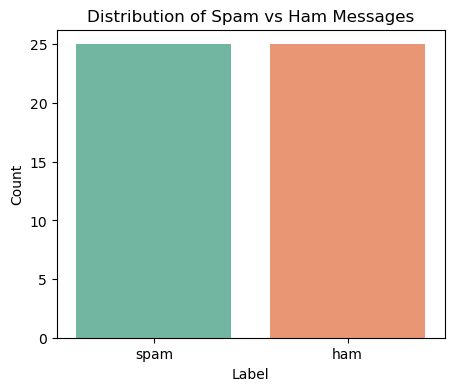

In [26]:
plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df, palette="Set2")
plt.title("Distribution of Spam vs Ham Messages")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## 5. Feature Extraction (Text to Numerical Vectors)

Machine learning models cannot work directly with raw text, so we convert each message into a numerical vector using the **Bag of Words** approach implemented via `CountVectorizer`.

In [27]:
vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["text"])

# Encode labels: spam = 1, ham = 0
y = df["label"].map({"spam": 1, "ham": 0})

print("Feature matrix shape:", X.shape)

Feature matrix shape: (50, 186)


## 6. Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 37
Testing samples: 13


## 7. Model Training

We use the **Multinomial Naive Bayes** algorithm, which is well suited for text classification problems involving word frequency features.

In [29]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## 8. Model Evaluation

In [30]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=["ham", "spam"]))

Model Accuracy: 84.62%

Classification Report:
              precision    recall  f1-score   support

         ham       0.80      1.00      0.89         8
        spam       1.00      0.60      0.75         5

    accuracy                           0.85        13
   macro avg       0.90      0.80      0.82        13
weighted avg       0.88      0.85      0.84        13



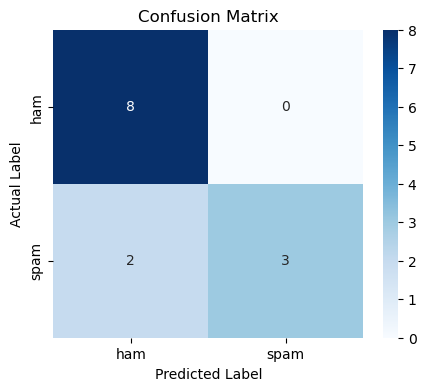

In [31]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## 9. Prediction Function

The function below takes any raw text message and returns whether it is predicted as **Spam** or **Ham**, along with the model's confidence score.

In [32]:
def check_spam(email_text):
    """
    Takes a raw email/message string and returns the predicted label
    along with the model's confidence score.
    """
    email_vector = vectorizer.transform([email_text])
    result = model.predict(email_vector)[0]
    probability = model.predict_proba(email_vector)[0]

    label = "SPAM" if result == 1 else "HAM (Not Spam)"
    confidence = probability[result] * 100

    return label, confidence

## 10. Testing on Sample Messages

In [33]:
test_emails = [
    "You have won a free lottery ticket, claim now!!",
    "Hey, let's meet for coffee tomorrow morning",
    "Get rich quick, click here now for free money",
    "Don't forget to submit the lab report by Friday",
]

for mail in test_emails:
    label, confidence = check_spam(mail)
    print(f"Message: {mail}")
    print(f"Prediction: {label}  (Confidence: {confidence:.2f}%)\n")

Message: You have won a free lottery ticket, claim now!!
Prediction: SPAM  (Confidence: 99.43%)

Message: Hey, let's meet for coffee tomorrow morning
Prediction: HAM (Not Spam)  (Confidence: 95.79%)

Message: Get rich quick, click here now for free money
Prediction: SPAM  (Confidence: 95.65%)

Message: Don't forget to submit the lab report by Friday
Prediction: HAM (Not Spam)  (Confidence: 93.76%)



## 11. Interactive Demo

Type any email or message text into the box below and click **Check Message** to see the model's live prediction.

> Note: This interactive widget requires `ipywidgets` to be installed and enabled in your Jupyter environment.

In [ ]:
text_input = widgets.Textarea(
    value="",
    placeholder="Type an email or message here...",
    description="Message:",
    layout=widgets.Layout(width="600px", height="100px")
)

check_button = widgets.Button(
    description="Check Message",
    button_style="success",
    icon="search"
)

output_area = widgets.Output()

def on_button_click(b):
    with output_area:
        clear_output()
        message = text_input.value.strip()
        if not message:
            print("Please enter a message to check.")
            return
        label, confidence = check_spam(message)
        color = "red" if label == "SPAM" else "green"
        print(f"Prediction: {label}")
        print(f"Confidence: {confidence:.2f}%")

check_button.on_click(on_button_click)

display(text_input, check_button, output_area)

Textarea(value='', description='Message:', layout=Layout(height='100px', width='600px'), placeholder='Type an …

Button(button_style='success', description='Check Message', icon='search', style=ButtonStyle())

Output()

## 12. Conclusion

This project demonstrates a basic text classification pipeline using the Bag of Words technique and a Multinomial Naive Bayes classifier to detect spam messages.

**Possible Future Improvements:**
- Use a larger, real-world dataset (e.g., the Kaggle SMS Spam Collection dataset)
- Apply TF-IDF vectorization instead of simple word counts
- Compare performance with other algorithms such as Logistic Regression or Support Vector Machines
- Add text preprocessing steps such as lemmatization and removal of punctuation/numbers